In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Data Science files/train_u6lujuX_CVtuZ9i.csv")
# Fill categorical columns with most frequent value
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Married'].fillna(df['Married'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)



/tmp/ipykernel_645/3600691027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
/tmp/ipykernel_645/3600691027.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

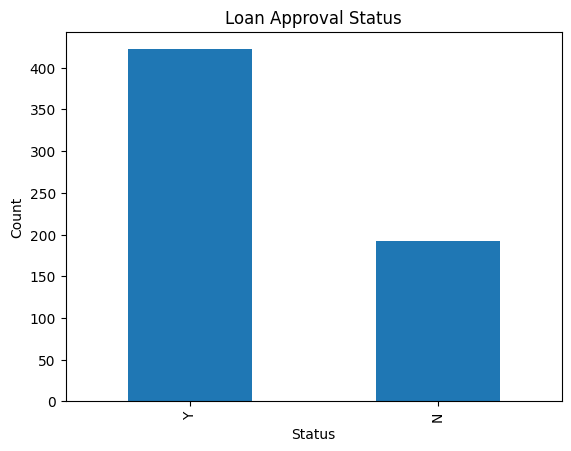

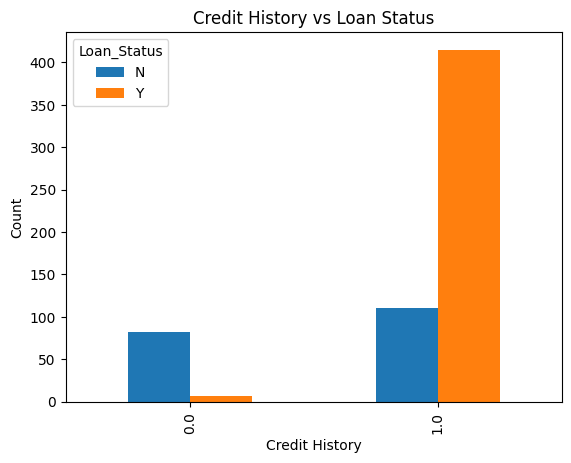

In [ ]:
# Fill numerical columns with median
df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Fill Credit_History with most frequent value
df['Credit_History'].fillna(df['Credit_History'].mode()[0])
import matplotlib.pyplot as plt
df['Loan_Status'].value_counts().plot(kind='bar')
plt.title('Loan Approval Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()
pd.crosstab(df['Credit_History'],df['Loan_Status']).plot(kind='bar')
plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.show()


In [ ]:
print("Gender:", df['Gender'].unique())

print("Married:", df['Married'].unique())

print("Dependents:", df['Dependents'].unique())

print("Education:", df['Education'].unique())

print("Self_Employed:", df['Self_Employed'].unique())

print("Property_Area:", df['Property_Area'].unique())

print("Loan_Status:", df['Loan_Status'].unique())

Gender: ['Male' 'Female']
Married: ['No' 'Yes']
Dependents: ['0' '1' '2' '3+']
Education: ['Graduate' 'Not Graduate']
Self_Employed: ['No' 'Yes']
Property_Area: ['Urban' 'Rural' 'Semiurban']
Loan_Status: ['Y' 'N']


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:

df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df['Gender'] = df['Gender'].replace({'Male':1, 'Female':0})
df['Married'] = df['Married'].replace({'Yes':1, 'No':0})

df['Education'] = df['Education'].replace({'Graduate':1, 'Not Graduate':0})

df['Self_Employed'] = df['Self_Employed'].replace({'Yes':1, 'No':0})

df['Loan_Status'] = df['Loan_Status'].replace({'Y':1, 'N':0})
df['Property_Area'] = df['Property_Area'].replace({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [ ]:
x=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7886178861788617


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[18 25]
 [ 1 79]]


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7642276422764228
